In [136]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
import shap
import pingouin as pg
from scipy.stats import wilcoxon, shapiro, spearmanr, chi2_contingency, randint, loguniform, uniform
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV, train_test_split, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

EDA + FEATURE ENGINEERING

In [137]:
from ucimlrepo import fetch_ucirepo 
  
heart_disease = fetch_ucirepo(id=45) 
  
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
X.value_counts()

X.rename(columns={
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'ChestPainType',
    'trestbps': 'RestingBP',
    'chol': 'Cholesterol',
    'fbs': 'FastingBS',
    'restecg': 'RestingECG',
    'thalach': 'MaxHR',
    'exang': 'ExerciseAngina',
    'oldpeak': 'Oldpeak',
    'slope': 'ST_Slope',
    'ca': 'MajorVessels',
    'thal': 'ThalliumTest'
}, inplace=True)

X['Sex'] = X['Sex'].map({0: 'F', 1: 'M'})
X['ChestPainType'] = X['ChestPainType'].map({1: 'TA', 2: 'ATA', 3: 'NAP', 4: 'ASY'})
X['RestingECG'] = X['RestingECG'].map({0: 'Normal', 1: 'ST', 2: 'LVH'})
X['ExerciseAngina'] = X['ExerciseAngina'].map({0: 'N', 1: 'Y'})
X['ST_Slope'] = X['ST_Slope'].map({1: 'Up', 2: 'Flat', 3: 'Down'})
y.rename(columns={'num': 'HeartDisease'}, inplace=True)
y['HeartDisease'] = y['HeartDisease'].map({0: 0, 1: 1,2: 1, 3: 1, 4: 1})
df = pd.concat([X, y], axis=1)

In [138]:
df[df.isnull().any(axis=1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,ThalliumTest,HeartDisease
87,53,F,NAP,128,216,0,LVH,115,N,0.0,Up,0.0,NaN,0
166,52,M,NAP,138,223,0,Normal,169,N,0.0,Up,NaN,3.0,0
192,43,M,ASY,132,247,1,LVH,143,Y,0.1,Flat,NaN,7.0,1
266,52,M,ASY,128,204,1,Normal,156,Y,1.0,Flat,0.0,NaN,1
287,58,M,ATA,125,220,0,Normal,144,N,0.4,Flat,NaN,7.0,0
302,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,NaN,3.0,0


In [139]:
df['ThalliumTest'] = df['ThalliumTest'].fillna(6.0)
df['ThalliumTest'].value_counts()

ThalliumTest
3.0    166
7.0    117
6.0     20
Name: count, dtype: int64

In [140]:
df['MajorVessels'] = df['MajorVessels'].fillna(3.0)
df['MajorVessels'].value_counts()

MajorVessels
0.0    176
1.0     65
2.0     38
3.0     24
Name: count, dtype: int64

In [141]:
df['ThalliumTest'] = df['ThalliumTest'].map({3.0: 'Normal', 6.0: 'FD', 7.0: 'RD'})
df['ThalliumTest'].value_counts()

ThalliumTest
Normal    166
RD        117
FD         20
Name: count, dtype: int64

In [142]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,MajorVessels,HeartDisease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,0.148515,149.607261,1.039604,0.702970,0.458746
std,9.038662,17.599748,51.776918,0.356198,22.875003,1.161075,0.968489,0.499120
min,29.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,0.000000,133.500000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,241.000000,0.000000,153.000000,0.800000,0.000000,0.000000
75%,61.000000,140.000000,275.000000,0.000000,166.000000,1.600000,1.000000,1.000000
max,77.000000,200.000000,564.000000,1.000000,202.000000,6.200000,3.000000,1.000000


In [143]:
df[(df['Cholesterol'] == 0) | (df['RestingBP'] == 0)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,ThalliumTest,HeartDisease


In [144]:
df['FastingBS'].unique()

array([1, 0])

In [145]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,ThalliumTest,HeartDisease
0,63,M,TA,145,233,1,LVH,150,N,2.3,Down,0.0,FD,0
1,67,M,ASY,160,286,0,LVH,108,Y,1.5,Flat,3.0,Normal,1
2,67,M,ASY,120,229,0,LVH,129,Y,2.6,Flat,2.0,RD,1
3,37,M,NAP,130,250,0,Normal,187,N,3.5,Down,0.0,Normal,0
4,41,F,ATA,130,204,0,LVH,172,N,1.4,Up,0.0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,0.0,RD,1
299,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,2.0,RD,1
300,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1.0,RD,1
301,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1.0,Normal,1


In [146]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS', 'ThalliumTest']
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'MajorVessels']

In [147]:
for i in num_cols:
    stat, p = shapiro(df[i])
    print(f'Shapiro-Wilk {i} = {stat:.3f}, p={p:.6f}')

Shapiro-Wilk Age = 0.986, p=0.006069
Shapiro-Wilk RestingBP = 0.967, p=0.000002
Shapiro-Wilk Cholesterol = 0.947, p=0.000000
Shapiro-Wilk MaxHR = 0.976, p=0.000070
Shapiro-Wilk Oldpeak = 0.844, p=0.000000
Shapiro-Wilk MajorVessels = 0.723, p=0.000000


In [148]:
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        col1 = num_cols[i]
        col2 = num_cols[j]
        
        corr, p = spearmanr(df[col1], df[col2])
        
        print(f"Teste spearmanr {col1}-{col2}: corr={corr:.6f}, p={p:.6f}")

Teste spearmanr Age-RestingBP: corr=0.292183, p=0.000000
Teste spearmanr Age-Cholesterol: corr=0.191253, p=0.000819
Teste spearmanr Age-MaxHR: corr=-0.391633, p=0.000000
Teste spearmanr Age-Oldpeak: corr=0.259895, p=0.000005
Teste spearmanr Age-MajorVessels: corr=0.354371, p=0.000000
Teste spearmanr RestingBP-Cholesterol: corr=0.135837, p=0.017996
Teste spearmanr RestingBP-MaxHR: corr=-0.040401, p=0.483529
Teste spearmanr RestingBP-Oldpeak: corr=0.150192, p=0.008833
Teste spearmanr RestingBP-MajorVessels: corr=0.083296, p=0.148051
Teste spearmanr Cholesterol-MaxHR: corr=-0.038301, p=0.506570
Teste spearmanr Cholesterol-Oldpeak: corr=0.034359, p=0.551313
Teste spearmanr Cholesterol-MajorVessels: corr=0.120625, p=0.035844
Teste spearmanr MaxHR-Oldpeak: corr=-0.431510, p=0.000000
Teste spearmanr MaxHR-MajorVessels: corr=-0.270206, p=0.000002
Teste spearmanr Oldpeak-MajorVessels: corr=0.239148, p=0.000026


In [149]:
df['Diff_Age_MaxHR'] = df['MaxHR'] - df['Age']
df['Age_MajorVessels_Sum'] = df['Age'] + df['MajorVessels']
df['MaxHR_Oldpeak_Sum'] = df['MaxHR'] + df['Oldpeak']

In [150]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Diff_Age_MaxHR', 'Age_MajorVessels_Sum', 'MaxHR_Oldpeak_Sum']
tree_num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [151]:
for i in num_cols:
    corr, p = spearmanr(df[i], df["HeartDisease"])
    print(f"Teste spearmanr {i}-HeartDisease: corr={corr:.6f}, p={p:.6f}")

Teste spearmanr Age-HeartDisease: corr=0.236674, p=0.000032
Teste spearmanr RestingBP-HeartDisease: corr=0.128166, p=0.025684
Teste spearmanr Cholesterol-HeartDisease: corr=0.121122, p=0.035082
Teste spearmanr MaxHR-HeartDisease: corr=-0.423467, p=0.000000
Teste spearmanr Oldpeak-HeartDisease: corr=0.413382, p=0.000000
Teste spearmanr Diff_Age_MaxHR-HeartDisease: corr=-0.430867, p=0.000000
Teste spearmanr Age_MajorVessels_Sum-HeartDisease: corr=0.273218, p=0.000001
Teste spearmanr MaxHR_Oldpeak_Sum-HeartDisease: corr=-0.411940, p=0.000000


In [152]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1 = cat_cols[i]
        col2 = cat_cols[j]
        
        cont_table = pd.crosstab(df[col1], df[col2])
        chi2, p, _, _ = chi2_contingency(cont_table)
        
        if p < 0.05:
            n = cont_table.sum().sum()
            cramer_v = np.sqrt(chi2 / (n * (min(cont_table.shape) - 1)))
            
            print(f"{col1} - {col2} | chi2={chi2:.2f}, p={p:.5f}, V={cramer_v:.3f}")

Sex - ExerciseAngina | chi2=5.83, p=0.01579, V=0.139
Sex - ThalliumTest | chi2=44.22, p=0.00000, V=0.382
ChestPainType - ExerciseAngina | chi2=66.01, p=0.00000, V=0.467
ChestPainType - ST_Slope | chi2=26.76, p=0.00016, V=0.210
ChestPainType - ThalliumTest | chi2=39.13, p=0.00000, V=0.254
RestingECG - ST_Slope | chi2=10.35, p=0.03492, V=0.131
ExerciseAngina - ST_Slope | chi2=25.13, p=0.00000, V=0.288
ExerciseAngina - ThalliumTest | chi2=32.93, p=0.00000, V=0.330
ST_Slope - ThalliumTest | chi2=33.79, p=0.00000, V=0.236


In [153]:
df['Bi_ExerciseAngina_ChestPainType'] = df['ExerciseAngina'] + '_' + df['ChestPainType']
df['Bi_ExerciseAngina_ThalliumTest'] = df['ExerciseAngina'] + '_' + df['ThalliumTest']
df['Bi_Sex_ThalliumTest'] = df['Sex'] + '_' + df['ThalliumTest']
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,ThalliumTest,HeartDisease,Diff_Age_MaxHR,Age_MajorVessels_Sum,MaxHR_Oldpeak_Sum,Bi_ExerciseAngina_ChestPainType,Bi_ExerciseAngina_ThalliumTest,Bi_Sex_ThalliumTest
0,63,M,TA,145,233,1,LVH,150,N,2.3,Down,0.0,FD,0,87,63.0,152.3,N_TA,N_FD,M_FD
1,67,M,ASY,160,286,0,LVH,108,Y,1.5,Flat,3.0,Normal,1,41,70.0,109.5,Y_ASY,Y_Normal,M_Normal
2,67,M,ASY,120,229,0,LVH,129,Y,2.6,Flat,2.0,RD,1,62,69.0,131.6,Y_ASY,Y_RD,M_RD
3,37,M,NAP,130,250,0,Normal,187,N,3.5,Down,0.0,Normal,0,150,37.0,190.5,N_NAP,N_Normal,M_Normal
4,41,F,ATA,130,204,0,LVH,172,N,1.4,Up,0.0,Normal,0,131,41.0,173.4,N_ATA,N_Normal,F_Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,0.0,RD,1,87,45.0,133.2,N_TA,N_RD,M_RD
299,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,2.0,RD,1,73,70.0,144.4,N_ASY,N_RD,M_RD
300,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1.0,RD,1,58,58.0,116.2,Y_ASY,Y_RD,M_RD
301,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1.0,Normal,1,117,58.0,174.0,N_ATA,N_Normal,F_Normal


In [154]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS', 'ThalliumTest', 'Bi_ExerciseAngina_ThalliumTest', 'Bi_ExerciseAngina_ChestPainType', 'Bi_Sex_ThalliumTest']
tree_cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS', 'ThalliumTest']

In [155]:
for i in cat_cols:
    cont_table = pd.crosstab(df[i], df["HeartDisease"])
    chi2, p, dof, expected = chi2_contingency(cont_table)
    print(f"chi2-{i}: {chi2}, p-value: {p}")

chi2-Sex: 22.042560606155472, p-value: 2.666712348180942e-06
chi2-ChestPainType: 81.81577027653815, p-value: 1.2517106007837527e-17
chi2-RestingECG: 10.051541372646057, p-value: 0.006566523814217354
chi2-ExerciseAngina: 54.68643453080239, p-value: 1.413788096718085e-13
chi2-ST_Slope: 45.78459111838959, p-value: 1.1428845467527021e-10
chi2-FastingBS: 0.07709504829488663, p-value: 0.7812734067063785
chi2-ThalliumTest: 83.09433830927527, p-value: 9.042607854203985e-19
chi2-Bi_ExerciseAngina_ThalliumTest: 106.38989545180301, p-value: 2.371837086650345e-21
chi2-Bi_ExerciseAngina_ChestPainType: 98.58661299648057, p-value: 2.1120888285565553e-18
chi2-Bi_Sex_ThalliumTest: 88.60883933230781, p-value: 1.316704895172151e-17


In [156]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,ThalliumTest,HeartDisease,Diff_Age_MaxHR,Age_MajorVessels_Sum,MaxHR_Oldpeak_Sum,Bi_ExerciseAngina_ChestPainType,Bi_ExerciseAngina_ThalliumTest,Bi_Sex_ThalliumTest
0,63,M,TA,145,233,1,LVH,150,N,2.3,Down,0.0,FD,0,87,63.0,152.3,N_TA,N_FD,M_FD
1,67,M,ASY,160,286,0,LVH,108,Y,1.5,Flat,3.0,Normal,1,41,70.0,109.5,Y_ASY,Y_Normal,M_Normal
2,67,M,ASY,120,229,0,LVH,129,Y,2.6,Flat,2.0,RD,1,62,69.0,131.6,Y_ASY,Y_RD,M_RD
3,37,M,NAP,130,250,0,Normal,187,N,3.5,Down,0.0,Normal,0,150,37.0,190.5,N_NAP,N_Normal,M_Normal
4,41,F,ATA,130,204,0,LVH,172,N,1.4,Up,0.0,Normal,0,131,41.0,173.4,N_ATA,N_Normal,F_Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,0.0,RD,1,87,45.0,133.2,N_TA,N_RD,M_RD
299,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,2.0,RD,1,73,70.0,144.4,N_ASY,N_RD,M_RD
300,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1.0,RD,1,58,58.0,116.2,Y_ASY,Y_RD,M_RD
301,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1.0,Normal,1,117,58.0,174.0,N_ATA,N_Normal,F_Normal


In [157]:
df.to_csv('heart_with_correctionsUCI.csv')

In [158]:
df.info()
df['HeartDisease'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              303 non-null    int64  
 1   Sex                              303 non-null    object 
 2   ChestPainType                    303 non-null    object 
 3   RestingBP                        303 non-null    int64  
 4   Cholesterol                      303 non-null    int64  
 5   FastingBS                        303 non-null    int64  
 6   RestingECG                       303 non-null    object 
 7   MaxHR                            303 non-null    int64  
 8   ExerciseAngina                   303 non-null    object 
 9   Oldpeak                          303 non-null    float64
 10  ST_Slope                         303 non-null    object 
 11  MajorVessels                     303 non-null    float64
 12  ThalliumTest          

HeartDisease
0    0.541254
1    0.458746
Name: proportion, dtype: float64

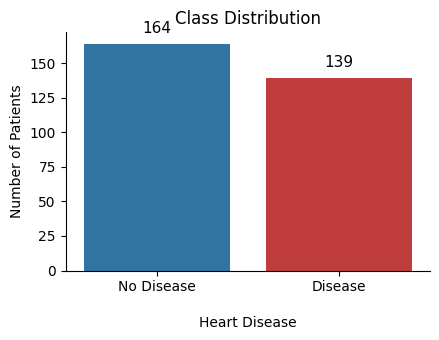

In [159]:
warnings.filterwarnings('ignore')
y = df['HeartDisease']
X = df.drop('HeartDisease', axis=1)
X_Tree = df.drop(['HeartDisease', 'Bi_ExerciseAngina_ThalliumTest', 'Bi_ExerciseAngina_ChestPainType', 'Bi_Sex_ThalliumTest', 'Diff_Age_MaxHR', 'Age_MajorVessels_Sum', 'MaxHR_Oldpeak_Sum'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
plt.figure(figsize=(4.5, 3.5))
ax = sns.countplot(
    data=df,
    x='HeartDisease',
    hue='HeartDisease',
    palette=['#1f77b4', '#d62728'],
    legend=False
)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 8,
            f'{int(height)}', ha="center", fontsize=11)

plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')
plt.title('Class Distribution')
plt.xticks(ticks=[0, 1], labels=['No Disease\n', 'Disease\n'])
sns.despine()
plt.tight_layout()
plt.savefig('images_UCI/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

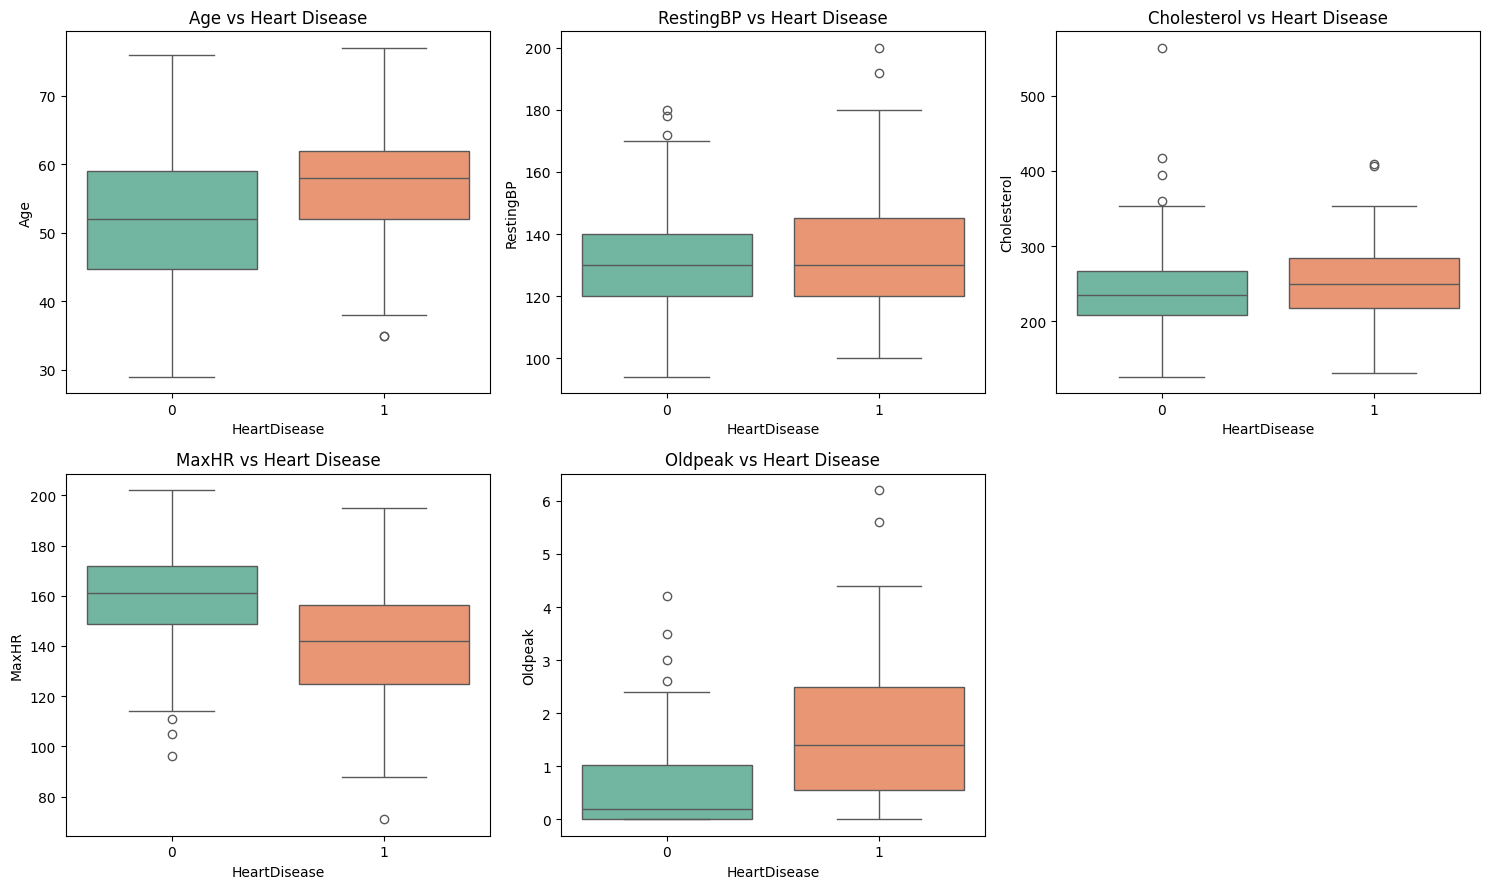

In [160]:
features = tree_num_cols
plt.figure(figsize=(15,9))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='HeartDisease', y=feature, palette='Set2')
    plt.title(f"{feature} vs Heart Disease")
    plt.savefig("images_UCI/numerics_by_heartdisease.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

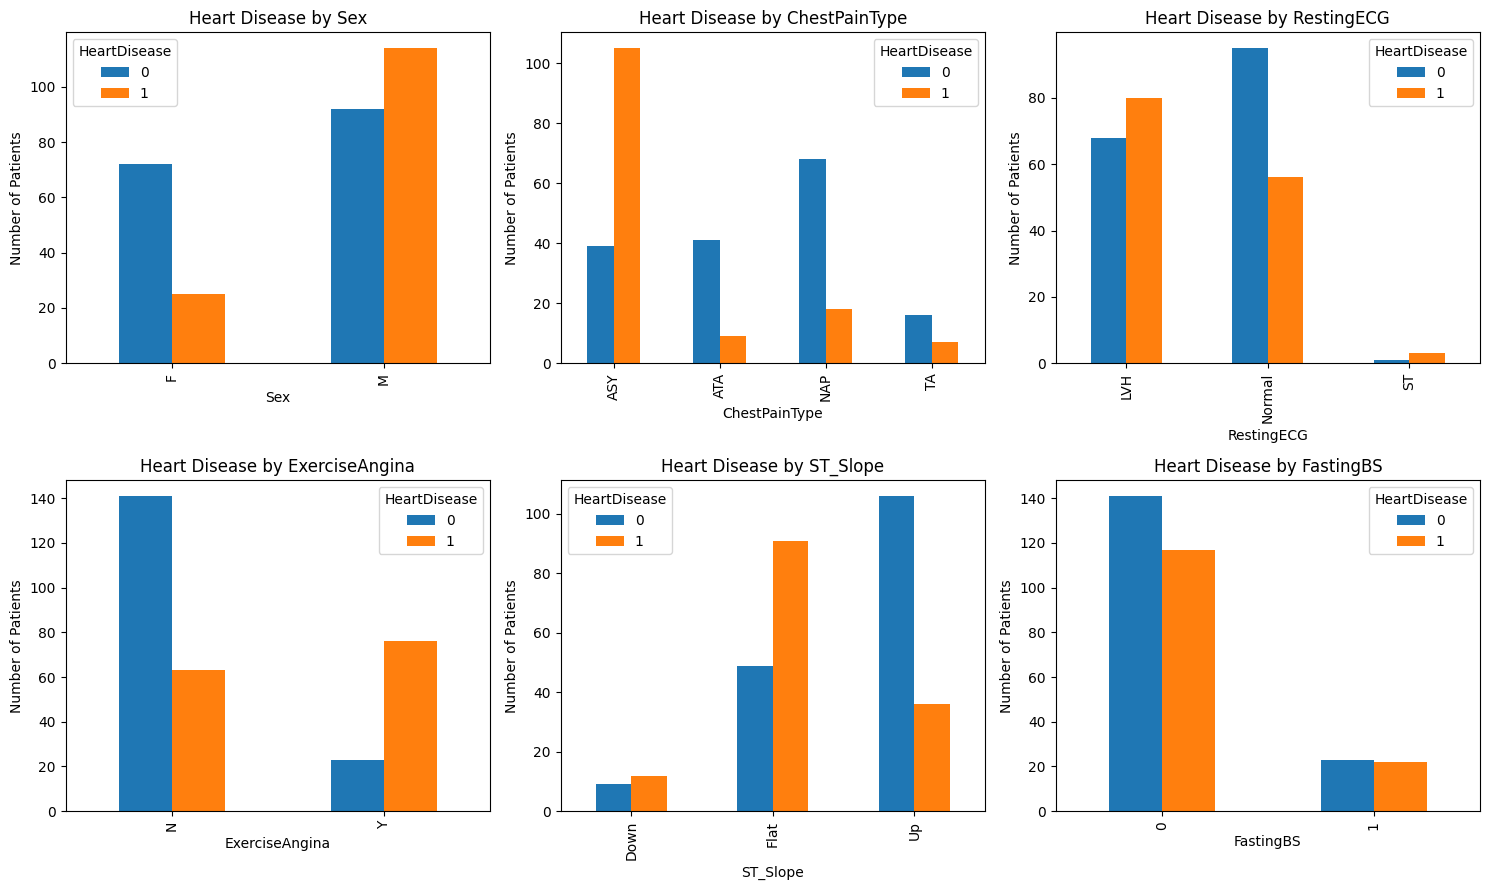

In [161]:
features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

plt.figure(figsize=(15, 9))

for i, feature in enumerate(features, 1):

    plt.subplot(2, 3, i)

    counts = df.groupby([feature, "HeartDisease"]).size().unstack()

    counts.plot(kind="bar", ax=plt.gca())

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.title(f"Heart Disease by {feature}")

plt.tight_layout()

plt.savefig('images_UCI/categoric_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Heart Disease by ThalliumTest')

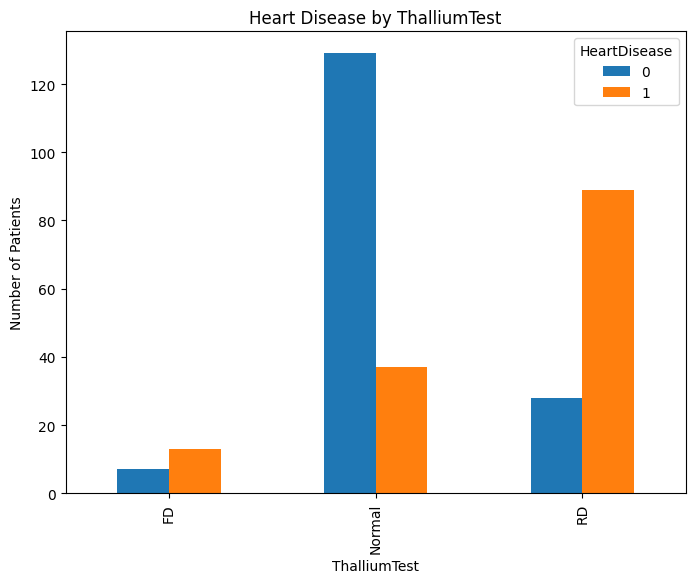

In [162]:
plt.figure(figsize=(8, 6))
counts = df.groupby(['ThalliumTest', "HeartDisease"]).size().unstack()

counts.plot(kind="bar", ax=plt.gca())

plt.xlabel('ThalliumTest')
plt.ylabel("Number of Patients")
plt.title(f"Heart Disease by ThalliumTest")

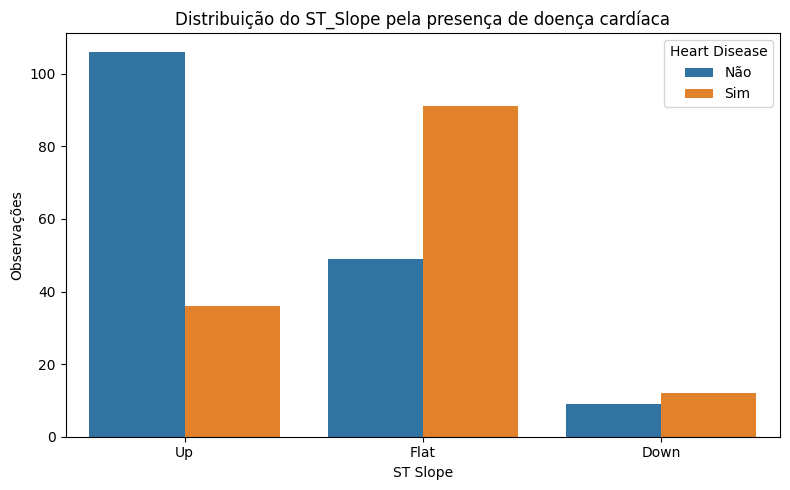

In [163]:
plt.figure(figsize=(8, 5))
order = ['Up', 'Flat', 'Down']
sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', order=order)
plt.title('Distribuição do ST_Slope pela presença de doença cardíaca')
plt.xlabel('ST Slope')
plt.ylabel('Observações')
plt.legend(title='Heart Disease', labels=['Não', 'Sim'])
plt.tight_layout()
plt.savefig('images_UCI/stslope_by_heartdisease.png', bbox_inches='tight')
plt.show()

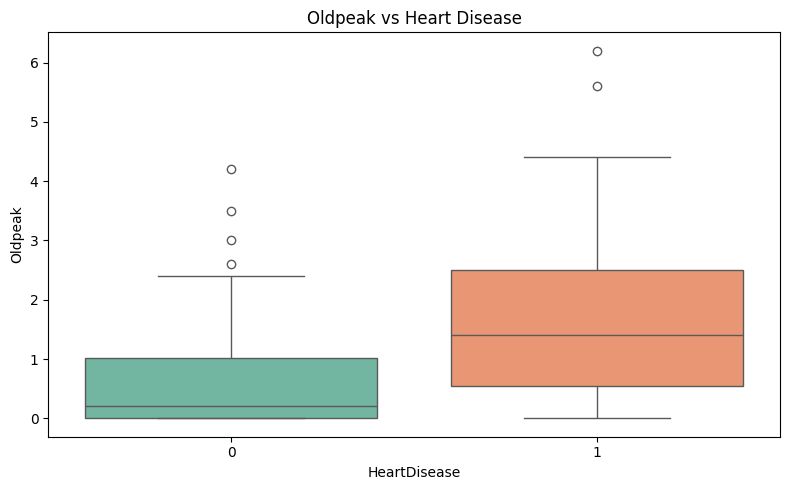

In [164]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='HeartDisease', y='Oldpeak', palette='Set2')
plt.title(f"Oldpeak vs Heart Disease")
plt.savefig("images_UCI/oldpeak_by_heartdisease.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

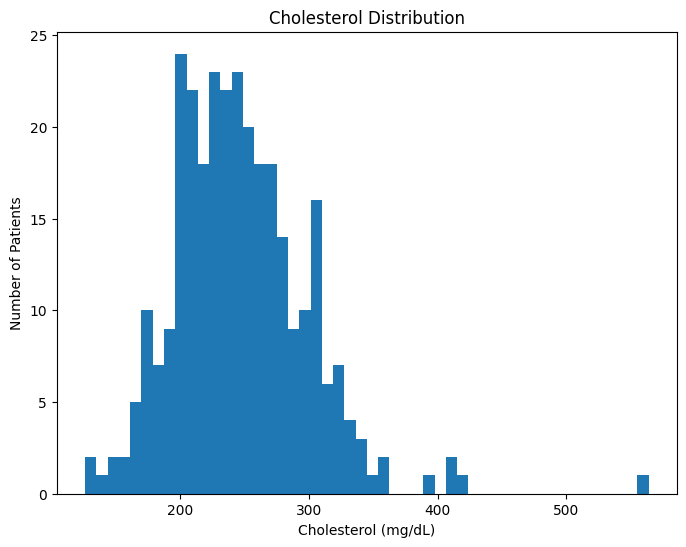

In [165]:
plt.figure(figsize=(8, 6))
plt.hist(x=df['Cholesterol'], bins=50);
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Number of Patients')
plt.title('Cholesterol Distribution')
plt.savefig('images_UCI/cholesterol_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

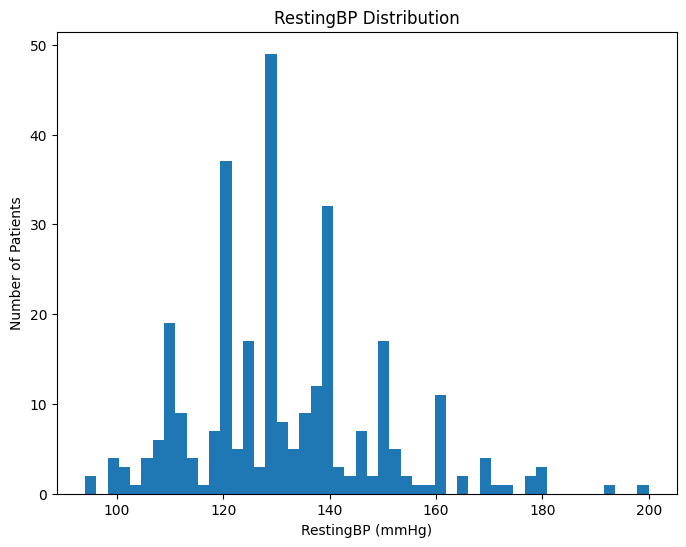

In [166]:
plt.figure(figsize=(8, 6))
plt.hist(x=df['RestingBP'], bins=50);
plt.xlabel('RestingBP (mmHg)')
plt.ylabel('Number of Patients')
plt.title('RestingBP Distribution')
plt.savefig('images_UCI/RestingBP_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

TREINAMENTO

In [167]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', tree_num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), tree_cat_cols)
])

preprocessor_nn = ColumnTransformer([
    ('num', StandardScaler(), tree_num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), tree_cat_cols)
])

In [168]:
param_grid_lr = {
    'clf__C': loguniform(1e-4, 100),
    'clf__penalty': ['l1', 'l2', 'elasticnet'], 
    'clf__solver': ['saga'],
    'clf__l1_ratio': uniform(0.1, 0.8),
    'clf__max_iter': [5000, 10000],
    'clf__class_weight': [None, 'balanced']
}

model1 = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        random_state=42,
        )
    ),
])

grid_lr = RandomizedSearchCV(
    estimator=model1,
    param_distributions=param_grid_lr,
    n_iter=200,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print(f"Melhor Score (AUC): {grid_lr.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_lr.best_params_}")

model1 = grid_lr.best_estimator_

scores_lr = cross_validate(model1, X_train, y_train, cv=10, scoring=['roc_auc', 'accuracy', 'recall', 'f1'], return_train_score=True, n_jobs=-1)

print("Logistic Regression AUC-ROC (10-fold):", scores_lr['test_roc_auc'].mean().round(4), "±", scores_lr['test_roc_auc'].std().round(4))
print("Accuracy:", scores_lr['test_accuracy'].mean().round(4))
print("Recall (doença):", scores_lr['test_recall'].mean().round(4))
print("F1-score:", scores_lr['test_f1'].mean().round(4))

print(f"Train AUC vs Test AUC: {scores_lr['train_roc_auc'].mean()} vs {scores_lr['test_roc_auc'].mean()}")

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
Melhor Score (AUC): 0.8763
Melhores Parâmetros: {'clf__C': np.float64(4.250799220467294), 'clf__class_weight': 'balanced', 'clf__l1_ratio': np.float64(0.68099592782065), 'clf__max_iter': 10000, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Logistic Regression AUC-ROC (10-fold): 0.8763 ± 0.0388
Accuracy: 0.8089
Recall (doença): 0.7763
F1-score: 0.7831
Train AUC vs Test AUC: 0.9320629959425156 vs 0.8762847222222223


In [169]:
param_grid_rf = {
    'clf__n_estimators': randint(200, 1200),
    'clf__max_depth': randint(5, 20),
    'clf__min_samples_split': randint(2, 15),
    'clf__min_samples_leaf': randint(1, 10),
    'clf__max_features': ['sqrt', 'log2', None],
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__bootstrap': [True, False],
    'clf__max_samples': uniform(0.6, 0.4),
    'clf__class_weight': [None, 'balanced'],
}

model2 = Pipeline([
    ('prep', preprocessor_tree),
    ('clf', RandomForestClassifier(
        random_state=42,
        criterion='entropy',
    ))
])

grid_rf = RandomizedSearchCV(
    estimator=model2,
    param_distributions=param_grid_rf,
    n_iter=100,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"Melhor Score (AUC): {grid_rf.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_rf.best_params_}")

model2 = grid_rf.best_estimator_

scores_rf = cross_validate(model2, X_train, y_train, cv=10, scoring=['roc_auc', 'accuracy', 'recall', 'f1'], return_train_score=True, n_jobs=-1)

print("Random Forest AUC-ROC (10-fold):", scores_rf['test_roc_auc'].mean().round(4), "±", scores_rf['test_roc_auc'].std().round(4))
print("Accuracy:", scores_rf['test_accuracy'].mean().round(4))
print("Recall (doença):", scores_rf['test_recall'].mean().round(4))
print("F1-score:", scores_rf['test_f1'].mean().round(4))

print(f"Train AUC vs Test AUC: {scores_rf['train_roc_auc'].mean()} vs {scores_rf['test_roc_auc'].mean()}")

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhor Score (AUC): 0.8611
Melhores Parâmetros: {'clf__bootstrap': True, 'clf__class_weight': 'balanced', 'clf__criterion': 'log_loss', 'clf__max_depth': 19, 'clf__max_features': 'log2', 'clf__max_samples': np.float64(0.9371065981137529), 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 8, 'clf__n_estimators': 466}
Random Forest AUC-ROC (10-fold): 0.8611 ± 0.0496
Accuracy: 0.7757
Recall (doença): 0.7769
F1-score: 0.7563
Train AUC vs Test AUC: 0.9348198117167357 vs 0.8611431623931625


In [170]:
param_grid_xgb = {
    'clf__n_estimators': randint(400, 1500),
    'clf__learning_rate': loguniform(0.005, 0.3),
    'clf__max_depth': randint(3, 10),
    'clf__min_child_weight': uniform(1, 10),
    'clf__gamma': uniform(0, 0.5),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__reg_alpha': loguniform(1e-4, 10),
    'clf__reg_lambda': loguniform(1e-2, 100),
    'clf__max_delta_step': randint(0, 5),
    'clf__scale_pos_weight': [1, 1.1, 1.2],
}

model3 = Pipeline([
    ('prep', preprocessor_tree),
    ('clf', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
    ))
])

grid_xgb = RandomizedSearchCV(
    estimator=model3,
    param_distributions=param_grid_xgb,
    n_iter=100,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print(f"Melhor Score (AUC): {grid_xgb.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_xgb.best_params_}")

model3 = grid_xgb.best_estimator_

scores_xgb = cross_validate(model3, X_train, y_train, cv=10, scoring=['roc_auc', 'accuracy', 'recall', 'f1'], return_train_score=True, n_jobs=-1)

print("XGBoost AUC-ROC (10-fold):", scores_xgb['test_roc_auc'].mean().round(4), "±", scores_xgb['test_roc_auc'].std().round(4))
print("Accuracy:", scores_xgb['test_accuracy'].mean().round(4))
print("Recall (doença):", scores_xgb['test_recall'].mean().round(4))
print("F1-score:", scores_xgb['test_f1'].mean().round(4))

print(f"Train AUC vs Test AUC: {scores_xgb['train_roc_auc'].mean()} vs {scores_xgb['test_roc_auc'].mean()}")

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhor Score (AUC): 0.8611
Melhores Parâmetros: {'clf__colsample_bytree': np.float64(0.9293696560681983), 'clf__gamma': np.float64(0.1447325131244595), 'clf__learning_rate': np.float64(0.009465394312244671), 'clf__max_delta_step': 3, 'clf__max_depth': 5, 'clf__min_child_weight': np.float64(7.713106657137283), 'clf__n_estimators': 1343, 'clf__reg_alpha': np.float64(1.1605298809664748), 'clf__reg_lambda': np.float64(0.08919301381945734), 'clf__scale_pos_weight': 1.2, 'clf__subsample': np.float64(0.6937203060977877)}
XGBoost AUC-ROC (10-fold): 0.8611 ± 0.0401
Accuracy: 0.7946
Recall (doença): 0.7686
F1-score: 0.7701
Train AUC vs Test AUC: 0.9329783409286243 vs 0.8611191239316239


In [171]:
param_grid_svm = {
    'clf__C': loguniform(1e-3, 100),
    'clf__gamma': loguniform(1e-4, 1e-1),
    'clf__kernel': ['rbf', 'poly', 'sigmoid'],
    'clf__degree': randint(2, 5),
    'clf__coef0': uniform(0, 1),
    'clf__class_weight': [None, 'balanced'],
    'clf__probability': [True]
}

svm_model = Pipeline([
    ('prep', preprocessor),
    ('clf', SVC(
        cache_size=1000,
        random_state=42
    ))
])

grid_svm = RandomizedSearchCV(
    svm_model,
    param_distributions=param_grid_svm,
    n_iter=200,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print(f"Melhor Score (AUC): {grid_svm.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_svm.best_params_}")

model4 = grid_svm.best_estimator_

scores_svm = cross_validate(model4, X_train, y_train, cv=10, scoring=['roc_auc', 'accuracy', 'recall', 'f1'], return_train_score=True, n_jobs=-1)

print("SVM AUC-ROC (10-fold):", scores_svm['test_roc_auc'].mean().round(4), "±", scores_svm['test_roc_auc'].std().round(4))
print("Accuracy:", scores_svm['test_accuracy'].mean().round(4))
print("Recall (doença):", scores_svm['test_recall'].mean().round(4))
print("F1-score:", scores_svm['test_f1'].mean().round(4))

print(f"Train AUC vs Test AUC: {scores_svm['train_roc_auc'].mean()} vs {scores_svm['test_roc_auc'].mean()}")

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
Melhor Score (AUC): 0.8703
Melhores Parâmetros: {'clf__C': np.float64(91.84067558150777), 'clf__class_weight': 'balanced', 'clf__coef0': np.float64(0.8873959696917767), 'clf__degree': 3, 'clf__gamma': np.float64(0.00018887419200969613), 'clf__kernel': 'poly', 'clf__probability': True}
SVM AUC-ROC (10-fold): 0.8703 ± 0.044
Accuracy: 0.7978
Recall (doença): 0.8096
F1-score: 0.7811
Train AUC vs Test AUC: 0.9006664368091784 vs 0.8703338675213675


In [172]:
df.shape

(303, 20)

In [173]:
param_grid_nn = {
    'clf__hidden_layer_sizes': [
        (11,), (50,), (100,), (150,),
        (50, 30), (100, 50), (150, 80),
        (80, 50, 30), (100, 60, 30),
        (60, 40, 25, 15)
    ],
    'clf__learning_rate_init': loguniform(1e-4, 0.1),
    'clf__solver': ['adam', 'sgd'],
    'clf__activation': ['relu', 'tanh', 'logistic'],
    'clf__alpha': loguniform(1e-5, 1e-1),
    'clf__batch_size': [32, 64, 128],
    'clf__momentum': uniform(0.0, 0.9),
    'clf__early_stopping': [True, False],
    'clf__max_iter': [1000, 2000, 3000]
}

neural_network = Pipeline([
    ('prep', preprocessor_nn),
    ('clf', MLPClassifier(
        random_state=42,
        max_iter=2000,
        tol=1e-6,
    ))
])

grid_nn = RandomizedSearchCV(
    neural_network,
    param_distributions=param_grid_nn,
    n_iter=50,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_nn.fit(X_train, y_train)

print(f"Melhor Score (AUC): {grid_nn.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_nn.best_params_}")

model5 = grid_nn.best_estimator_

scores_nn = cross_validate(model5, X_train, y_train, cv=10, scoring=['roc_auc', 'accuracy', 'recall', 'f1'], return_train_score=True, n_jobs=-1)

print("Neural Network AUC-ROC (10-fold):", scores_nn['test_roc_auc'].mean().round(4), "±", scores_nn['test_roc_auc'].std().round(4))
print("Accuracy:", scores_nn['test_accuracy'].mean().round(4))
print("Recall (doença):", scores_nn['test_recall'].mean().round(4))
print("F1-score:", scores_nn['test_f1'].mean().round(4))

print(f"Train AUC vs Test AUC: {scores_nn['train_roc_auc'].mean()} vs {scores_nn['test_roc_auc'].mean()}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits


Melhor Score (AUC): 0.8644
Melhores Parâmetros: {'clf__activation': 'tanh', 'clf__alpha': np.float64(0.06716426178131797), 'clf__batch_size': 32, 'clf__early_stopping': True, 'clf__hidden_layer_sizes': (50, 30), 'clf__learning_rate_init': np.float64(0.0031224894060836415), 'clf__max_iter': 1000, 'clf__momentum': np.float64(0.8921132249939444), 'clf__solver': 'adam'}
Neural Network AUC-ROC (10-fold): 0.8644 ± 0.0352
Accuracy: 0.8015
Recall (doença): 0.7776
F1-score: 0.7773
Train AUC vs Test AUC: 0.9060849648218104 vs 0.864423076923077


In [174]:
stack = StackingClassifier(
    estimators=[
        ('lr', model1),
        ('rf', model2),
        ('xgb', model3),
        ('svm', model4),
        ('nn', model5),
    ],
    final_estimator=LogisticRegression(),
    cv=10,
    stack_method='predict_proba',
    n_jobs=-1
)

stack.fit(X_train, y_train)

scores_stack = cross_validate(
    stack,
    X_train,
    y_train,
    cv=10,
    scoring=['roc_auc', 'accuracy', 'recall', 'f1'], 
    return_train_score=True,
    n_jobs=-1
)

print("Stack AUC-ROC (10-fold):", scores_stack['test_roc_auc'].mean().round(4), "±", scores_stack['test_roc_auc'].std().round(4))
print("Accuracy:", scores_stack['test_accuracy'].mean().round(4))
print("Recall (doença):", scores_stack['test_recall'].mean().round(4))
print("F1-score:", scores_stack['test_f1'].mean().round(4))

print(f"Train AUC vs Test AUC: {scores_stack['train_roc_auc'].mean()} vs {scores_stack['test_roc_auc'].mean()}")

Stack AUC-ROC (10-fold): 0.8694 ± 0.0346
Accuracy: 0.7979
Recall (doença): 0.7513
F1-score: 0.7668
Train AUC vs Test AUC: 0.9315479652615378 vs 0.8694364316239316


In [175]:
joblib.dump(model1, 'best_logistic_regressionUCI.pkl')
joblib.dump(model2, 'best_random_forestUCI.pkl')
joblib.dump(model3, 'best_xgboostUCI.pkl')
joblib.dump(model4, 'best_svmUCI.pkl')
joblib.dump(model5, 'best_nnUCI.pkl')
joblib.dump(stack, 'stackingUCI.pkl')

['stackingUCI.pkl']

ANÁLISE DE MÉTRICAS

In [176]:
model1 = joblib.load('best_logistic_regressionUCI.pkl')
model2 = joblib.load('best_random_forestUCI.pkl')
model3 = joblib.load('best_xgboostUCI.pkl')
model4 = joblib.load('best_svmUCI.pkl')
model5 = joblib.load('best_nnUCI.pkl')
stack = joblib.load('stackingUCI.pkl')

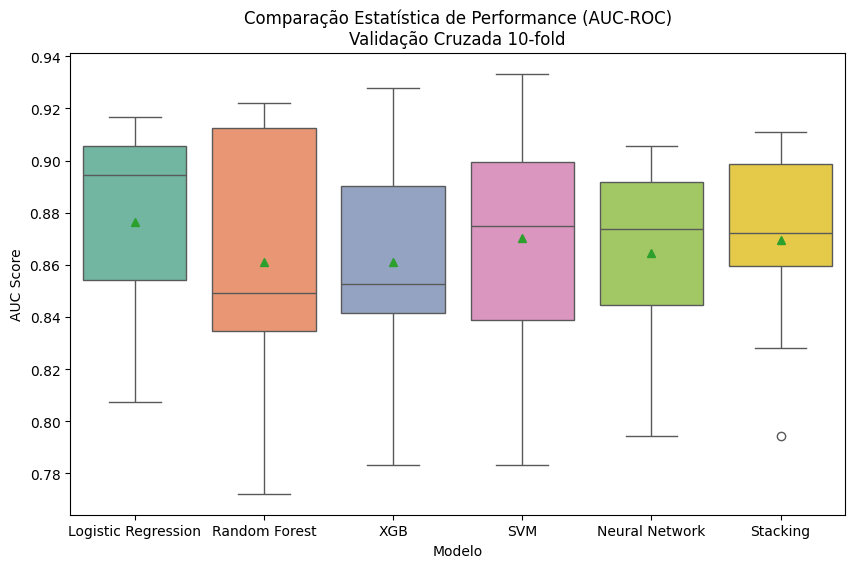

In [177]:
results = []
names = []
models = [('Logistic Regression', model1), ('Random Forest', model2), ('XGB', model3), ('SVM', model4), ('Neural Network', model5), ('Stacking', stack)]
scores = [('Logistic Regression', scores_lr), ('Random Forest', scores_rf), ('XGB', scores_xgb), ('SVM', scores_svm), ('Neural Network', scores_nn), ('Stacking', scores_stack)]

for name, model in scores:
    results.append(model['test_roc_auc'])
    names.append(name)

data = []
for name, score in scores:
    for s in score['test_roc_auc']:
        data.append({'Modelo': name, 'AUC-ROC': s})

df_plot = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot,
    x='Modelo',
    y='AUC-ROC',
    palette='Set2',
    showmeans=True,
)

plt.title('Comparação Estatística de Performance (AUC-ROC)\nValidação Cruzada 10-fold')
plt.ylabel('AUC Score')
plt.savefig('images_UCI/model_comparison_boxplot.png')
plt.show()

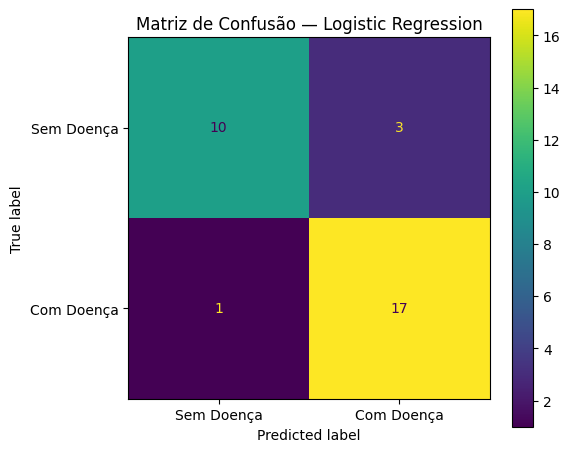

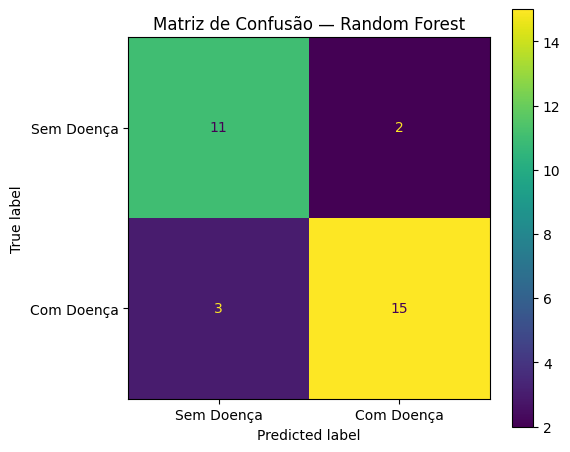

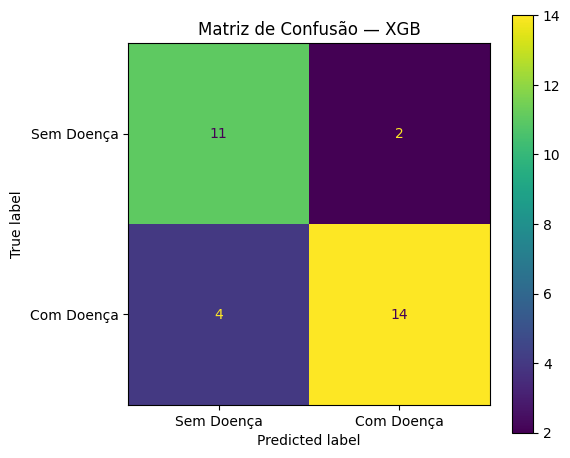

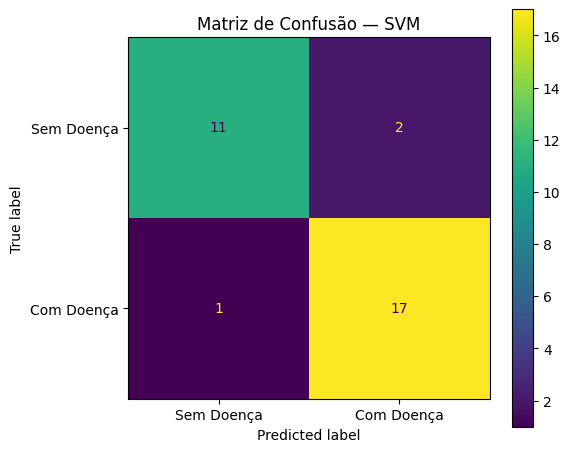

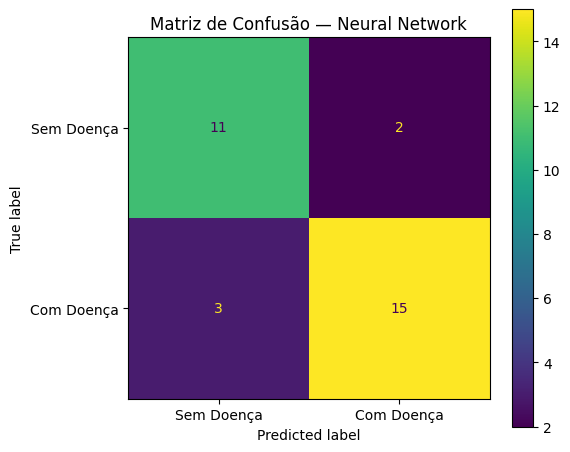

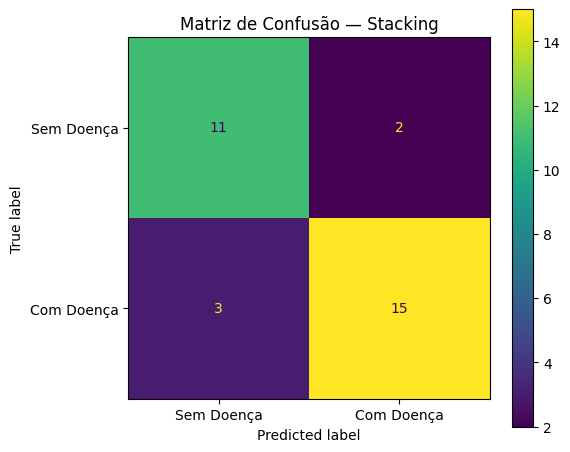

In [178]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models:
    y_pred = model.predict(X_test)
    conf_matrix_total = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_total,
                                  display_labels=['Sem Doença', 'Com Doença'])
    disp.plot(cmap='viridis', ax=plt.gca(), values_format='d')
    plt.title(f'Matriz de Confusão — {name}')
    plt.tight_layout()
    plt.savefig(f'images_UCI/cm_{name.lower().replace(" ", "")}.png', bbox_inches='tight')
    plt.show()
    plt.close()

In [179]:
for name, model in models:
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_proba)
    
    print(f"{name} - AUC Teste: {auc_score:.4f}")

Logistic Regression - AUC Teste: 0.9402
Random Forest - AUC Teste: 0.9487
XGB - AUC Teste: 0.9402
SVM - AUC Teste: 0.9359
Neural Network - AUC Teste: 0.9444
Stacking - AUC Teste: 0.9444


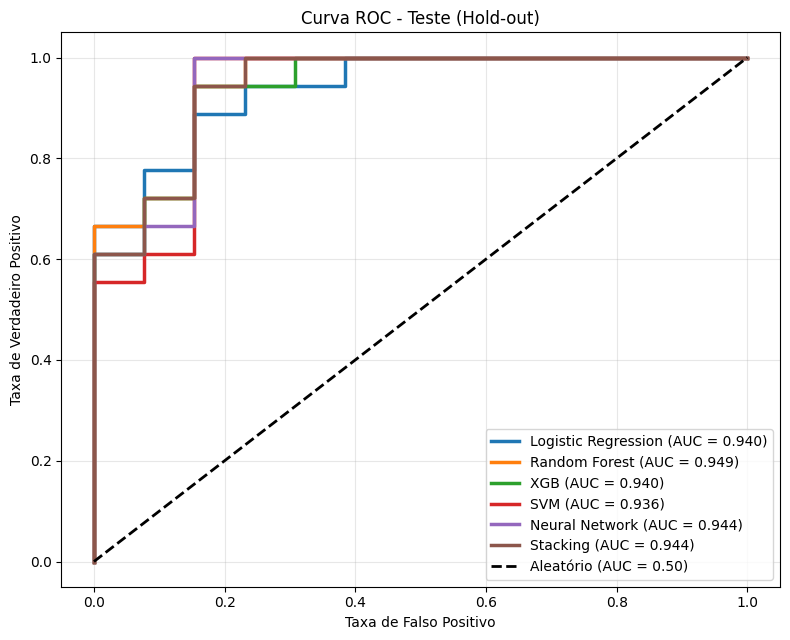

In [180]:
plt.figure(figsize=(8, 6.5))

colors = ['blue', 'green', 'red', 'orange', 'purple', 'black']

for i, (name, model) in enumerate(models):

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)

    auc_score = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, lw=2.5,
             label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC - Teste (Hold-out)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images_UCI/roc_curve_final.png', dpi=300)
plt.show()

In [181]:
X_sample = X_test.copy()
X_proc_rf = model2.named_steps['prep'].transform(X_sample)
X_proc_xgb = model3.named_steps['prep'].transform(X_sample)
prep = model2.named_steps['prep']
feature_names = (
    num_cols +
    list(prep.named_transformers_['cat'].get_feature_names_out(tree_cat_cols))
)

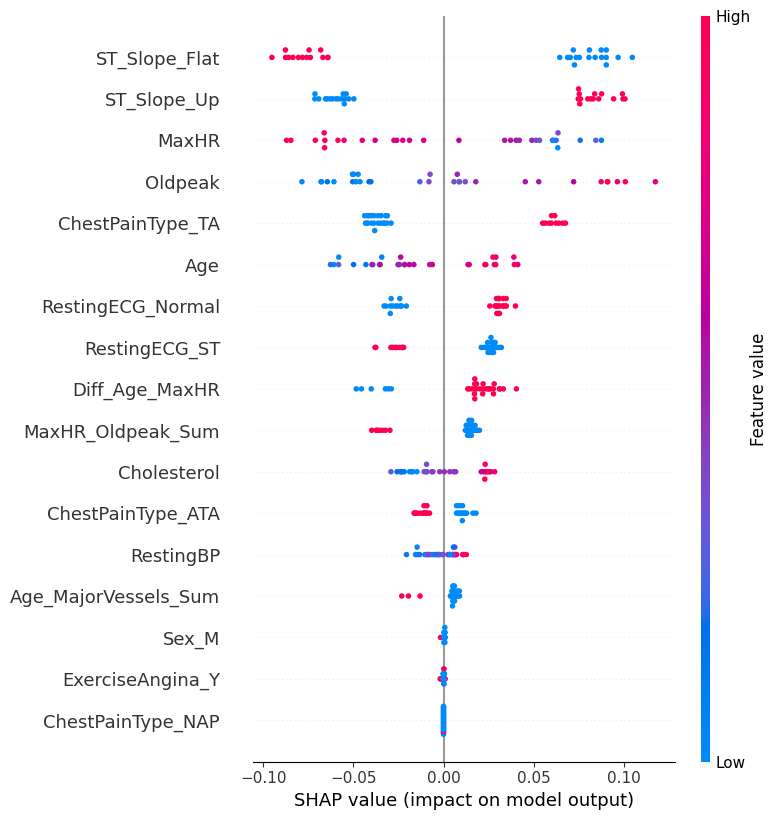

In [182]:
rf_clf = model2.named_steps['clf']

explainer_rf = shap.TreeExplainer(rf_clf)
shap_values_rf = explainer_rf.shap_values(X_proc_rf)
shap_to_plot_rf = shap_values_rf[:, :, 1]

shap.summary_plot(
    shap_to_plot_rf,
    X_proc_rf,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig("images_UCI/shap_summary_rf.png", dpi=300, bbox_inches="tight")
plt.show()

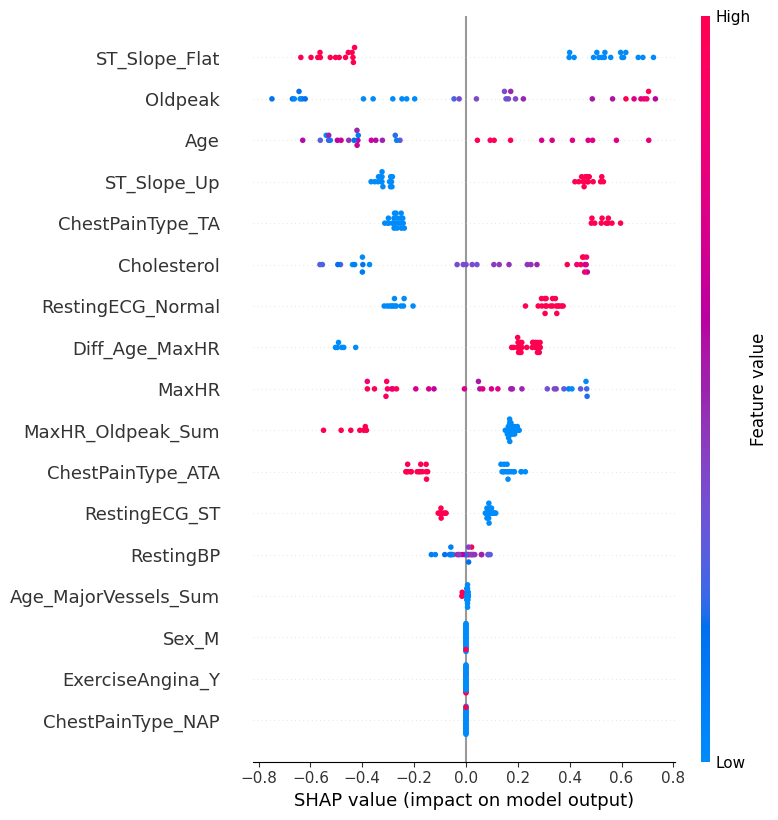

In [183]:
explainer_xgb = shap.TreeExplainer(model3.named_steps['clf'])
shap_values_xgb = explainer_xgb.shap_values(X_proc_xgb)

shap.summary_plot(
    shap_values_xgb,
    X_proc_xgb,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig("images_UCI/shap_summary_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

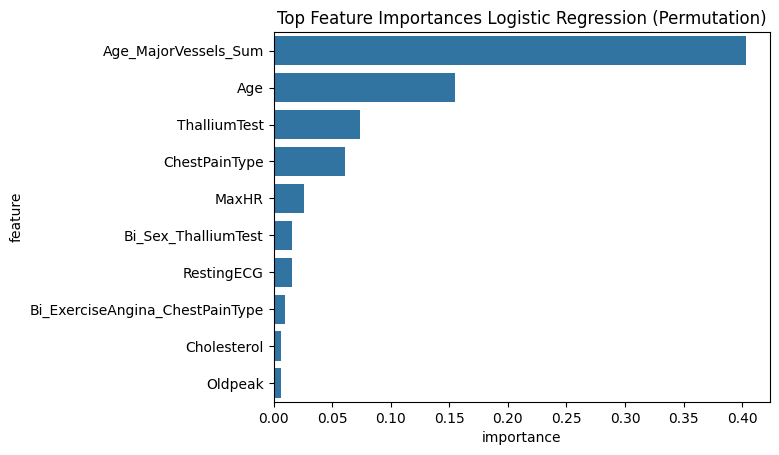

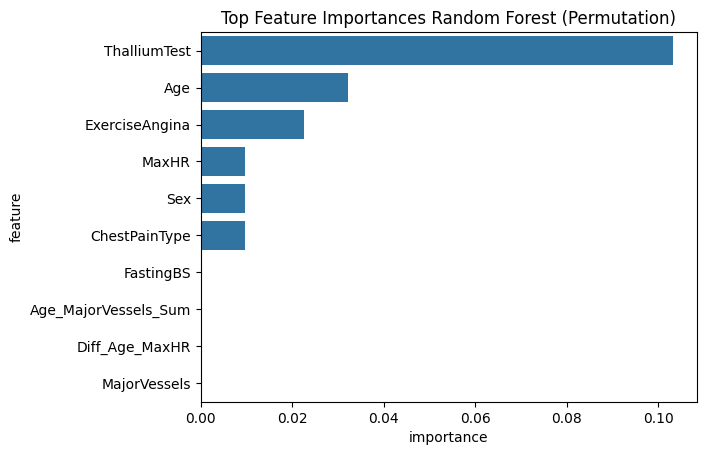

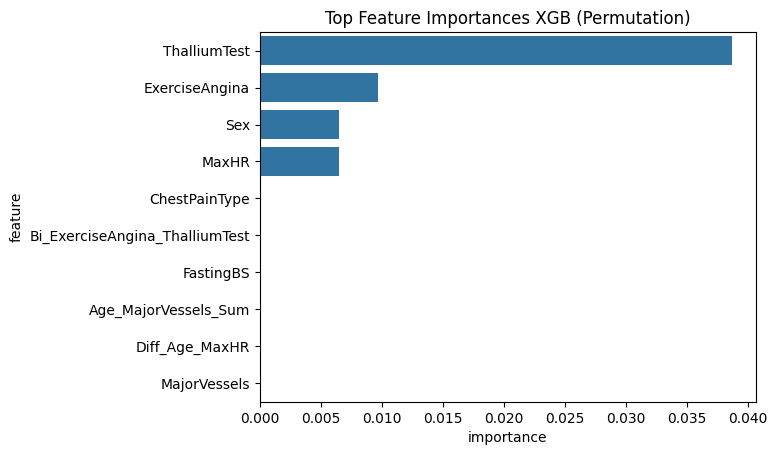

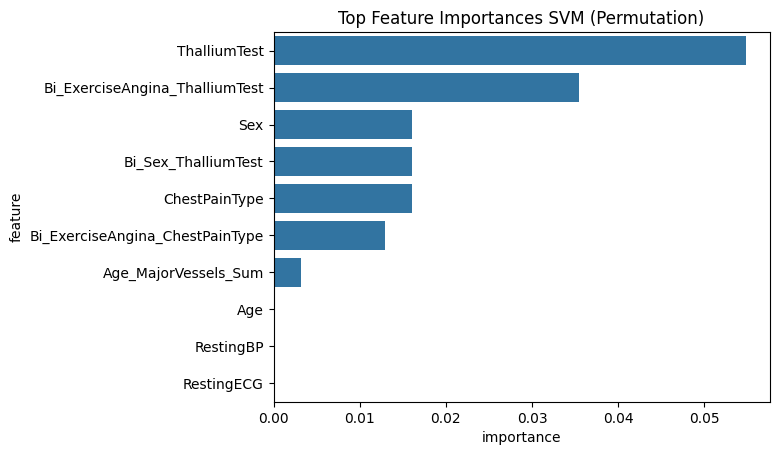

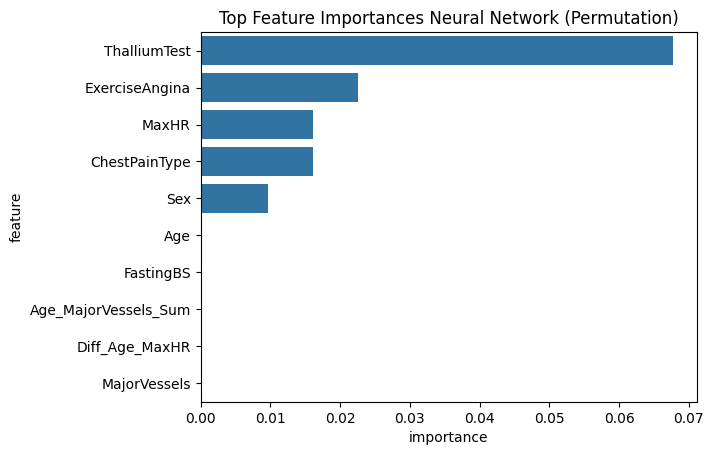

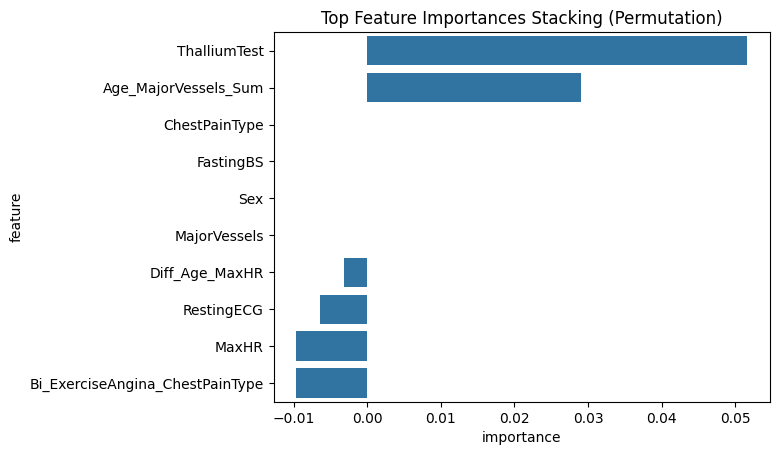

In [184]:
for name, model in models:
    r = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': r.importances_mean,
        'std': r.importances_std
    }).sort_values(by='importance', ascending=False)

    df_plot = importance_df.head(10)

    plt.figure()
    ax = sns.barplot(x='importance', y='feature', data=df_plot)
    plt.title(f'Top Feature Importances {name} (Permutation)')
    plt.show()

In [185]:
df_test = pd.read_csv('./heart.csv')

In [201]:
X_test = df_test.drop('HeartDisease', axis=1)
y_test = df_test['HeartDisease']

In [202]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,ThalliumTest,HeartDisease,Diff_Age_MaxHR,Age_MajorVessels_Sum,MaxHR_Oldpeak_Sum,Bi_ExerciseAngina_ChestPainType,Bi_ExerciseAngina_ThalliumTest,Bi_Sex_ThalliumTest
0,63,M,TA,145,233,1,LVH,150,N,2.3,Down,0.0,FD,0,87,63.0,152.3,N_TA,N_FD,M_FD
1,67,M,ASY,160,286,0,LVH,108,Y,1.5,Flat,3.0,Normal,1,41,70.0,109.5,Y_ASY,Y_Normal,M_Normal
2,67,M,ASY,120,229,0,LVH,129,Y,2.6,Flat,2.0,RD,1,62,69.0,131.6,Y_ASY,Y_RD,M_RD
3,37,M,NAP,130,250,0,Normal,187,N,3.5,Down,0.0,Normal,0,150,37.0,190.5,N_NAP,N_Normal,M_Normal
4,41,F,ATA,130,204,0,LVH,172,N,1.4,Up,0.0,Normal,0,131,41.0,173.4,N_ATA,N_Normal,F_Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,0.0,RD,1,87,45.0,133.2,N_TA,N_RD,M_RD
299,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,2.0,RD,1,73,70.0,144.4,N_ASY,N_RD,M_RD
300,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1.0,RD,1,58,58.0,116.2,Y_ASY,Y_RD,M_RD
301,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1.0,Normal,1,117,58.0,174.0,N_ATA,N_Normal,F_Normal


In [203]:
X_test.rename(columns={'ThaliumTest': 'ThalliumTest'}, inplace=True)

In [214]:
prob = pd.crosstab(X_train['ChestPainType'], X_train['ThalliumTest'], normalize='index')

In [215]:
def sample_from_dist(cp):
    if cp in prob.index:
        return np.random.choice(prob.columns, p=prob.loc[cp].values)
    else:
        return np.random.choice(prob.columns)

X_test['ThalliumTest'] = X_test['ChestPainType'].apply(sample_from_dist)

In [218]:
X_test

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ThalliumTest
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,Normal
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,Normal
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,Normal
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,Normal
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,RD
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,RD
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,Normal
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,Normal
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,FD


In [216]:
y_pred = model2.predict(X_test)

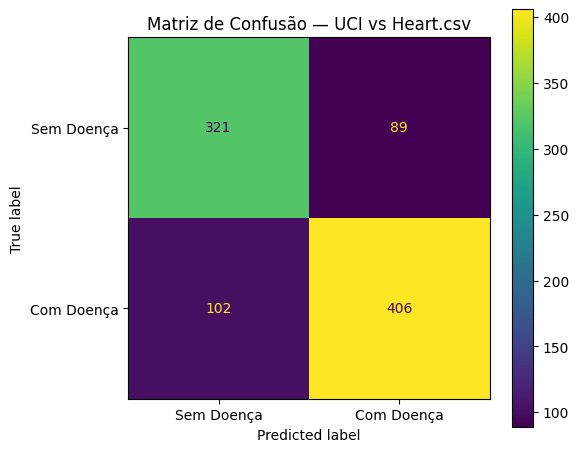

In [217]:
conf_matrix_total = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_total,
                                display_labels=['Sem Doença', 'Com Doença'])
disp.plot(cmap='viridis', ax=plt.gca(), values_format='d')
plt.title(f'Matriz de Confusão — UCI vs Heart.csv')
plt.tight_layout()
plt.show()
plt.close()